In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

ROOT = Path("/Users/mitchellheaton/stat486/STAT486_FINAL")
df = pd.read_csv(ROOT / "data" / "listings.csv")

# Parse price
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .replace(["", "NA", "N/A"], pd.NA)
    .astype("float64")
)

# Log transform target — drop rows where price is missing or <= 0
df = df[df["price"] > 0].copy()
df["log_price"] = np.log(df["price"])

In [3]:
FEATURES = [
    "bedrooms", "accommodates", "bathrooms",
    "review_scores_rating", "minimum_nights",
    "calculated_host_listings_count",
    "room_type", "neighbourhood_group_cleansed",
    "neighbourhood_cleansed"
]
TARGET = "log_price"

# Drop rows missing target or all features
model_df = df[FEATURES + [TARGET]].dropna(subset=[TARGET])

X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 17132, Test size: 4283


In [4]:
numeric_features = [
    "bedrooms", "accommodates", "bathrooms",
    "review_scores_rating", "minimum_nights",
    "calculated_host_listings_count"
]

categorical_features = [
    "room_type", "neighbourhood_group_cleansed",
    "neighbourhood_cleansed"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [5]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)
lr_cv = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring="r2")

print(f"Linear Regression — Test RMSE: {lr_rmse:.4f} | Test R²: {lr_r2:.4f}")
print(f"CV R² (5-fold): {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")

Linear Regression — Test RMSE: 0.5719 | Test R²: 0.6171
CV R² (5-fold): 0.6322 ± 0.0225


In [6]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_params = {
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_leaf": [5, 10, 20]
}

dt_search = GridSearchCV(dt_pipeline, dt_params, cv=5, scoring="r2", n_jobs=-1)
dt_search.fit(X_train, y_train)

best_dt = dt_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)

print(f"Best params: {dt_search.best_params_}")
print(f"Decision Tree  — Test RMSE: {dt_rmse:.4f} | Test R²: {dt_r2:.4f}")

Best params: {'model__max_depth': 12, 'model__min_samples_leaf': 5}
Decision Tree  — Test RMSE: 0.4952 | Test R²: 0.7129


In [7]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 12, None],
    "model__min_samples_leaf": [5, 10]
}

rf_search = GridSearchCV(rf_pipeline, rf_params, cv=5, scoring="r2", n_jobs=-1)
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Best params: {rf_search.best_params_}")
print(f"Random Forest  — Test RMSE: {rf_rmse:.4f} | Test R²: {rf_r2:.4f}")

Best params: {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
Random Forest  — Test RMSE: 0.4598 | Test R²: 0.7524


In [11]:
# Train predictions
y_train_pred_lr = lr_pipeline.predict(X_train)
y_train_pred_dt = best_dt.predict(X_train)
y_train_pred_rf = best_rf.predict(X_train)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "Train RMSE": [
        np.sqrt(mean_squared_error(y_train, y_train_pred_lr)),
        np.sqrt(mean_squared_error(y_train, y_train_pred_dt)),
        np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
    ],
    "Test RMSE": [lr_rmse, dt_rmse, rf_rmse],
    "Train R²": [
        r2_score(y_train, y_train_pred_lr),
        r2_score(y_train, y_train_pred_dt),
        r2_score(y_train, y_train_pred_rf)
    ],
    "Test R²": [lr_r2, dt_r2, rf_r2]
})

print(results.to_string(index=False))

            Model  Train RMSE  Test RMSE  Train R²  Test R²
Linear Regression    0.539398   0.571861  0.643029 0.617080
    Decision Tree    0.405662   0.495180  0.798097 0.712887
    Random Forest    0.354527   0.459849  0.845789 0.752397


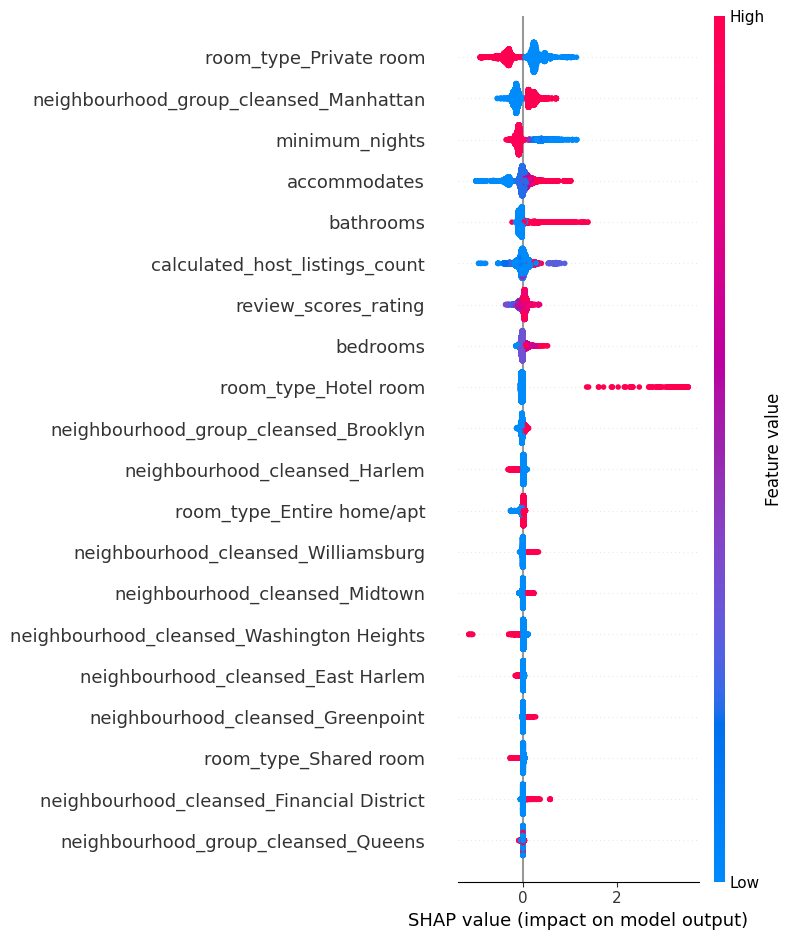

In [9]:
# Get preprocessed training data for SHAP
X_train_transformed = best_rf.named_steps["preprocessor"].transform(X_train)

# Get feature names after encoding
cat_feature_names = best_rf.named_steps["preprocessor"] \
    .named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# SHAP TreeExplainer
explainer = shap.TreeExplainer(best_rf.named_steps["model"])
shap_values = explainer.shap_values(X_train_transformed)

# Summary plot — save for your figures/ folder
shap.summary_plot(shap_values, X_train_transformed, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.savefig("../progress/figures/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

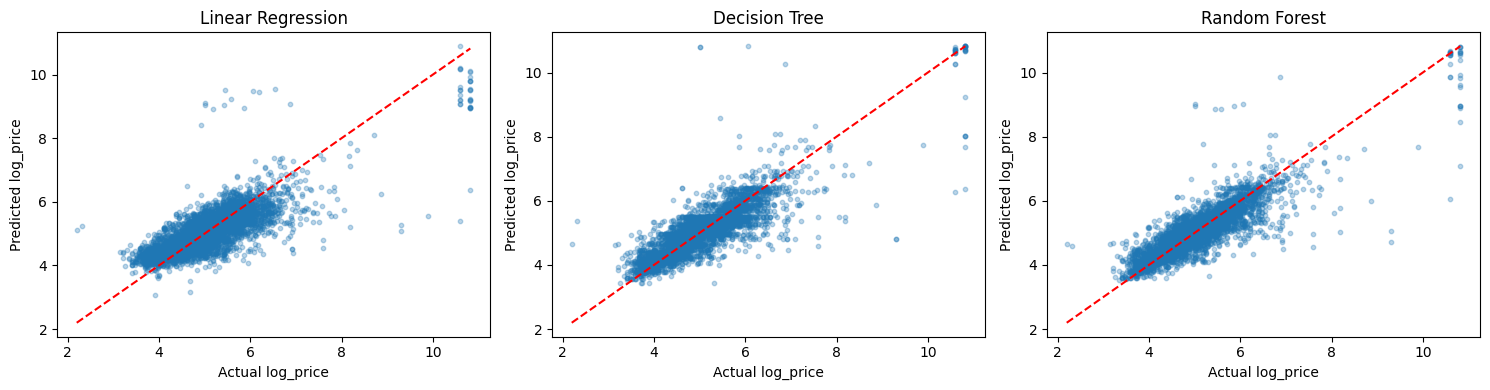

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, preds, title in zip(axes,
    [y_pred_lr, y_pred_dt, y_pred_rf],
    ["Linear Regression", "Decision Tree", "Random Forest"]):
    ax.scatter(y_test, preds, alpha=0.3, s=10)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    ax.set_xlabel("Actual log_price")
    ax.set_ylabel("Predicted log_price")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("../progress/figures/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
print("Model Performance Summary")
print("=" * 90)
print(f"{'Model':<20} {'Best Params':<35} {'Train RMSE':>10} {'Test RMSE':>10} {'Train R²':>9} {'Test R²':>8}")
print("-" * 90)

print(f"{'Linear Regression':<20} {'None':35} {np.sqrt(mean_squared_error(y_train, y_train_pred_lr)):>10.3f} {lr_rmse:>10.3f} {r2_score(y_train, y_train_pred_lr):>9.3f} {lr_r2:>8.3f}")
print(f"{'Decision Tree':<20} {str(dt_search.best_params_):<35} {np.sqrt(mean_squared_error(y_train, y_train_pred_dt)):>10.3f} {dt_rmse:>10.3f} {r2_score(y_train, y_train_pred_dt):>9.3f} {dt_r2:>8.3f}")
print(f"{'Random Forest':<20} {str(rf_search.best_params_):<35} {np.sqrt(mean_squared_error(y_train, y_train_pred_rf)):>10.3f} {rf_rmse:>10.3f} {r2_score(y_train, y_train_pred_rf):>9.3f} {rf_r2:>8.3f}")
print(f"\nLinear Regression CV R²: {lr_cv.mean():.3f} ± {lr_cv.std():.3f}")

Model Performance Summary
Model                Best Params                         Train RMSE  Test RMSE  Train R²  Test R²
------------------------------------------------------------------------------------------
Linear Regression    None                                     0.539      0.572     0.643    0.617
Decision Tree        {'model__max_depth': 12, 'model__min_samples_leaf': 5}      0.406      0.495     0.798    0.713
Random Forest        {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}      0.355      0.460     0.846    0.752

Linear Regression CV R²: 0.632 ± 0.022
